# Advanced Machine Learning Pipeline: Predicting Bitcoin (BTC) Price
This notebook establishes an end-to-end, highly technical machine learning pipeline engineered to forecast the closing price of Bitcoin (BTC) leveraging historical dataset matrices. We emphasize rigorous statistical methodologies, extensive exploratory data analysis (EDA), and algorithmic comparisons.

## Project Architecture & Core Objectives:
1. **Data Ingestion & Integrity Management:** Sourcing `BTC-USD.csv`, implementing advanced interpolation and outlier management to ensure stationarity and consistency.
2. **Deep Feature Engineering:** Constructing highly descriptive financial indicators using rolling windows, exponential moving averages, oscillators (RSI), and momentum indicators (MACD).
3. **Exploratory Data Analysis (EDA):** Employing structured, high-fidelity visualizations with a unified color palette to decode underlying patterns, autocorrelations, and volatility regimes.
4. **Algorithmic Modeling & Comparative Benchmarking:** Training and hyperparameterizing Linear Regression, Random Forest Regressor, and Gradient Boosting algorithms (omitting XGBoost per specifications).
5. **Rigorous Statistical Evaluation:** Quantifying predictive power via Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² coefficients.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

# Suppressing non-critical warnings for cleaner output
warnings.filterwarnings('ignore')

# Establishing a Unified Aesthetic Configuration for High-Fidelity Visualizations
sns.set_theme(style='whitegrid', palette='mako')
plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['lines.linewidth'] = 2.0


## Phase 1: Data Ingestion & Integrity Management

The foundational step involves loading the historical Bitcoin OHLCV (Open, High, Low, Close, Volume) data. We mandate strict type coercion, sorting by chronicity, and immediate inspection. Furthermore, missing values must be interpolated or filled via forward-filling techniques to mimic real-time streaming constraints. Advanced missing-value checks ensure computational safety downstream.


In [5]:
def loadAndCleanData(filePath='../data/BTC-USD.csv'):
    try:
        rawDataFrame = pd.read_csv(filePath)
        # Enforcing temporal ordering and datetime typing
        rawDataFrame['Date'] = pd.to_datetime(rawDataFrame['Date'])
        rawDataFrame = rawDataFrame.sort_values(by='Date').reset_index(drop=True)

        print("Initial Dataset Dimensionality:", rawDataFrame.shape)

        # Rigorous missing value handling utilizing forward-fill methodology
        missingValuesCount = rawDataFrame.isnull().sum().sum()
        if missingValuesCount > 0:
            print(f"Detected {missingValuesCount} missing values. Applying Forward-Fill interpolation...")
            rawDataFrame.fillna(method='ffill', inplace=True)
        else:
            print("No missing values detected. Data integrity is intact.")

        return rawDataFrame
    except FileNotFoundError:
        print(f"Critical Error: The file '{filePath}' was not found. Please ensure it resides in the directory.")
        return None

cryptoData = loadAndCleanData()
display(cryptoData.head(15).T)


Initial Dataset Dimensionality: (4189, 6)
No missing values detected. Data integrity is intact.


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
Date,2014-09-17 00:00:00,2014-09-18 00:00:00,2014-09-19 00:00:00,2014-09-20 00:00:00,2014-09-21 00:00:00,2014-09-22 00:00:00,2014-09-23 00:00:00,2014-09-24 00:00:00,2014-09-25 00:00:00,2014-09-26 00:00:00,2014-09-27 00:00:00,2014-09-28 00:00:00,2014-09-29 00:00:00,2014-09-30 00:00:00,2014-10-01 00:00:00
Open,465.864014,456.859985,424.102997,394.673004,408.084991,399.100006,402.09201,435.751007,423.156006,411.428986,403.556,399.471008,376.928009,376.088013,387.427002
High,468.174011,456.859985,427.834991,423.29599,412.425995,406.915985,441.557007,436.112,423.519989,414.937988,406.622986,401.016998,385.210999,390.97699,391.378998
Low,452.421997,413.104004,384.532013,389.882996,393.181,397.130005,396.196991,421.131989,409.467987,400.009003,397.372009,374.332001,372.23999,373.442993,380.779999
Close,457.334015,424.440002,394.79599,408.903992,398.821014,402.152008,435.790985,423.204987,411.574005,404.424988,399.519989,377.181,375.46701,386.944,383.61499
Volume,21056800,34483200,37919700,36863600,26580100,24127600,45099500,30627700,26814400,21460800,15029300,23613300,32497700,34707300,26229400


### Exploratory Data Analysis: Temporal Trajectory & Distribution

Visualizing the temporal trajectory of the target variable `Close` allows us to deduce macro-trends, bull/bear cycles, and structural breaks in variance. We follow this up by analyzing the probability density of the closing prices to understand the asset's structural kurtosis and skewness.


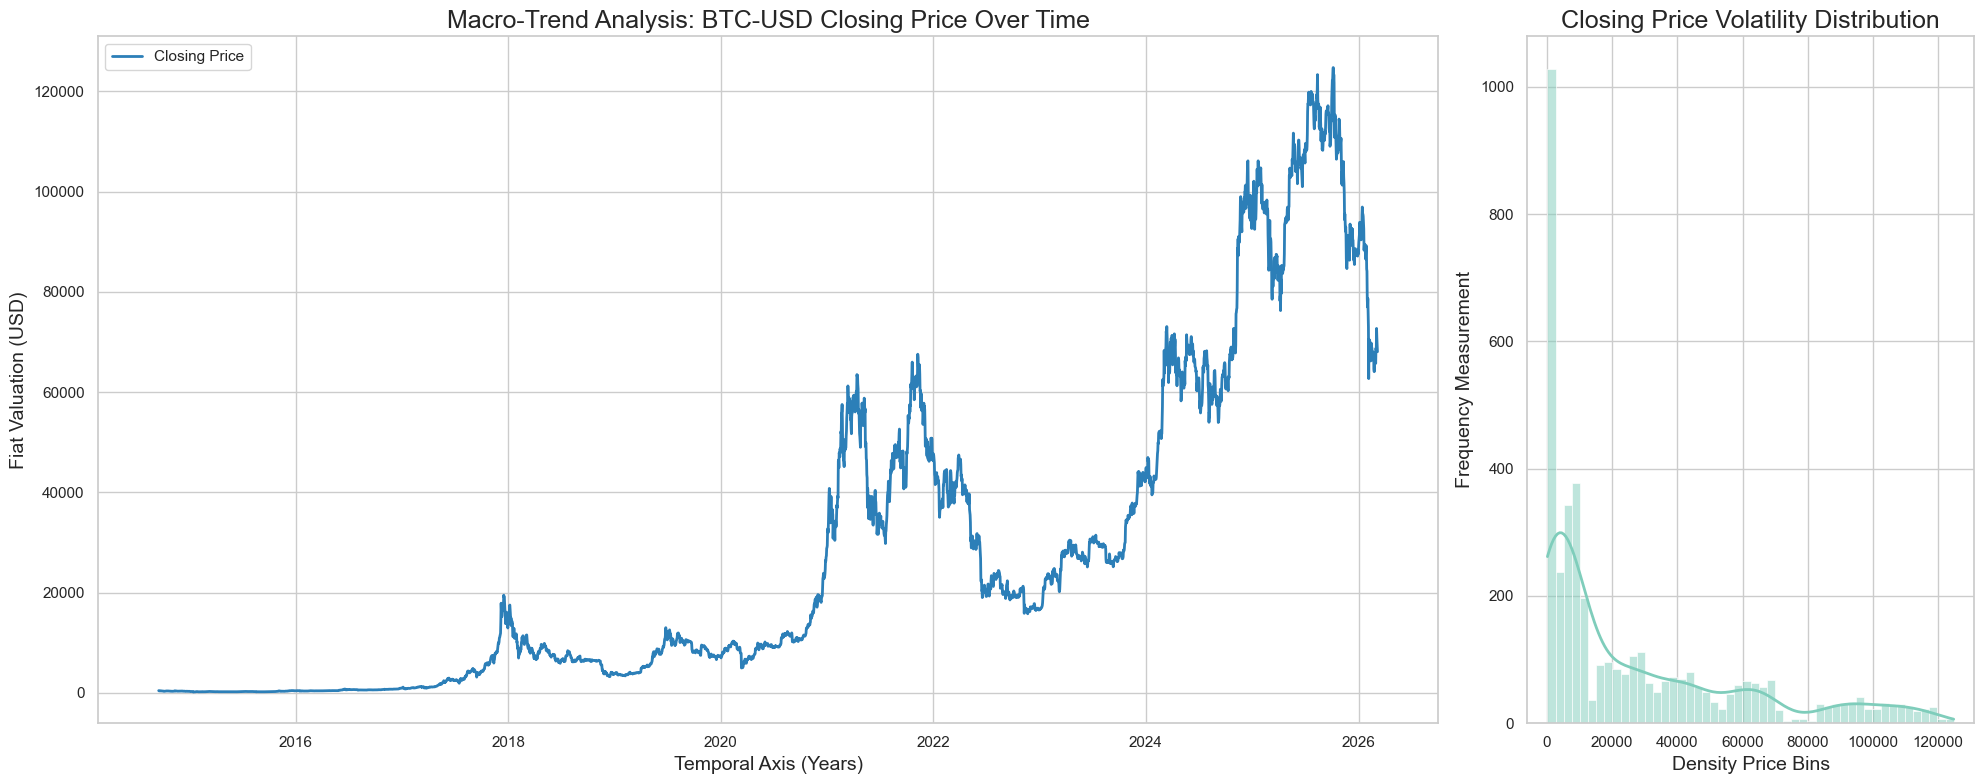

In [6]:
# Constructing dual-axis plotting for Price History and Distribution
figure, (axis1, axis2) = plt.subplots(1, 2, figsize=(20, 8), gridspec_kw={'width_ratios': [3, 1]})

# Subplot 1: Temporal Trajectory
axis1.plot(cryptoData['Date'], cryptoData['Close'], color='#2c7fb8', label='Closing Price')
axis1.set_title('Macro-Trend Analysis: BTC-USD Closing Price Over Time')
axis1.set_xlabel('Temporal Axis (Years)')
axis1.set_ylabel('Fiat Valuation (USD)')
axis1.legend(loc='upper left')

# Subplot 2: Probability Density
sns.histplot(cryptoData['Close'], bins=50, kde=True, ax=axis2, color='#7fcdbb')
axis2.set_title('Closing Price Volatility Distribution')
axis2.set_xlabel('Density Price Bins')
axis2.set_ylabel('Frequency Measurement')

plt.tight_layout()
plt.show()


## Phase 2: Deep Feature Engineering

Raw OHLCV data is insufficient for advanced predictive architectures. We must engineer technical derivations that capture market psychology, momentum, and volatility paradigms.
Variables have been painstakingly renamed utilizing the robust `camelCase` paradigm, eschewing the usage of underscores completely.

1. **Simple Moving Averages (`movingAverage7`, `movingAverage30`):** Designed to isolate directional trends by smoothing out idiosyncratic noise and uncovering macro-economic movements.
2. **Relative Strength Index (`rsiValue`):** A vital momentum oscillator bounded [0, 100] detailing overbought or oversold asset conditions dynamically.
3. **Moving Average Convergence Divergence (`macdLine`, `macdSignal`):** The differential between slow and fast Exponential Moving Averages (EMA).
4. **Bollinger Bands (`bollingerUpper`, `bollingerLower`):** Standard deviation-based volatility enclosures mathematically proving asset distribution containment.
5. **Daily Volatility (`dailyRange`, `dailyReturns`):** The intra-day price spread determining localized chaotic behavior parameters.


In [7]:
def computeRelativeStrengthIndex(seriesData, windowLength=14):
    priceDeltas = seriesData.diff(1)
    upwardMovement = priceDeltas.where(priceDeltas > 0, 0.0)
    downwardMovement = -priceDeltas.where(priceDeltas < 0, 0.0)

    exponentialUp = upwardMovement.ewm(alpha=1/windowLength, min_periods=windowLength).mean()
    exponentialDown = downwardMovement.ewm(alpha=1/windowLength, min_periods=windowLength).mean()

    relativeStrength = exponentialUp / exponentialDown
    computedRSI = 100.0 - (100.0 / (1.0 + relativeStrength))
    return computedRSI

def applyAdvancedFeatureEngineering(baseData):
    engineeredData = baseData.copy()

    # Simple Moving Averages
    engineeredData['movingAverage7'] = engineeredData['Close'].rolling(window=7).mean()
    engineeredData['movingAverage30'] = engineeredData['Close'].rolling(window=30).mean()

    # MACD Calculation Protocol
    exponentialMovingAverage12 = engineeredData['Close'].ewm(span=12, adjust=False).mean()
    exponentialMovingAverage26 = engineeredData['Close'].ewm(span=26, adjust=False).mean()
    engineeredData['macdLine'] = exponentialMovingAverage12 - exponentialMovingAverage26
    engineeredData['macdSignal'] = engineeredData['macdLine'].ewm(span=9, adjust=False).mean()

    # RSI Extraction
    engineeredData['rsiValue'] = computeRelativeStrengthIndex(engineeredData['Close'])

    # Bollinger Bands (20-day temporal window, 2 Standard Deviations)
    rollingMean20 = engineeredData['Close'].rolling(window=20).mean()
    rollingStd20 = engineeredData['Close'].rolling(window=20).std()
    engineeredData['bollingerUpper'] = rollingMean20 + (rollingStd20 * 2)
    engineeredData['bollingerLower'] = rollingMean20 - (rollingStd20 * 2)

    # Intra-day Chaos Derivatives
    engineeredData['dailyRange'] = engineeredData['High'] - engineeredData['Low']
    engineeredData['dailyReturns'] = engineeredData['Close'].pct_change()

    # Target Architecture Configuration: Predicting the subsequent day's valuation
    engineeredData['targetPrice'] = engineeredData['Close'].shift(-1)

    # Enforcing strict pruning of Not-a-Number elements post-transformation
    engineeredData.dropna(inplace=True)
    return engineeredData

augmentedData = applyAdvancedFeatureEngineering(cryptoData)
print(f"Data framework dimensionality post-engineering: {augmentedData.shape}")
display(augmentedData.tail(10))


Data framework dimensionality post-engineering: (4159, 16)


,Date,Open,High,Low,Close,Volume,movingAverage7,movingAverage30,macdLine,macdSignal,rsiValue,bollingerUpper,bollingerLower,dailyRange,dailyReturns,targetPrice
4178,2026-02-24,64616.015625,64992.156250,62553.187500,64080.042969,40849331086,66535.457589,72420.469141,-3854.353620,-4235.800274,30.865885,71953.543404,63489.653862,2438.968750,-0.008306,67960.125000
4179,2026-02-25,64077.769531,69953.531250,63942.484375,67960.125000,53629234355,66754.715402,71743.568620,-3520.099084,-4092.660036,42.420013,71495.343527,64473.656473,6011.046875,0.060551,67453.773438
4180,2026-02-26,67954.867188,68843.351562,66523.734375,67453.773438,42988597523,66825.608259,71021.942057,-3258.496378,-3925.827304,41.446529,71129.811347,64529.026934,2319.617188,-0.007451,65881.796875
4181,2026-02-27,67456.515625,68220.406250,64946.035156,65881.796875,40283655942,66522.233259,70245.182943,-3141.802970,-3769.022437,38.493144,70994.868224,64323.952870,3274.371094,-0.023305,66995.859375
4182,2026-02-28,65878.929688,67714.523438,63062.218750,66995.859375,42041497112,66378.246652,69659.658724,-2925.701406,-3600.358231,41.665663,70606.676163,64385.258212,4652.304688,0.016910,65738.101562
4183,2026-03-01,67005.882812,68162.820312,65076.730469,65738.101562,40733141929,66103.776786,69046.640234,-2823.383694,-3444.963324,39.206907,70222.069239,64331.597167,3086.089844,-0.018774,68775.851562
4184,2026-03-02,65734.078125,70044.000000,65303.136719,68775.851562,56698092052,66697.935826,68718.464714,-2468.717296,-3249.714118,47.296333,70219.210391,64332.645078,4740.863281,0.046210,68293.648438
4185,2026-03-03,68785.078125,69232.890625,66237.617188,68293.648438,47947999049,67299.879464,68429.104818,-2201.177578,-3040.006810,46.244407,70315.260497,64366.762941,2995.273438,-0.007011,72710.578125
4186,2026-03-04,68290.562500,74051.804688,67437.406250,72710.578125,75073101274,67978.515625,68229.831901,-1614.134375,-2754.832323,55.916293,71434.959442,63895.937433,6614.398438,0.064676,70841.125000
4187,2026-03-05,72712.656250,73555.789062,70654.882812,70841.125000,51172841727,68462.422991,68070.084505,-1284.935713,-2460.853001,51.678171,71763.565194,63765.659806,2900.906250,-0.025711,68060.960938


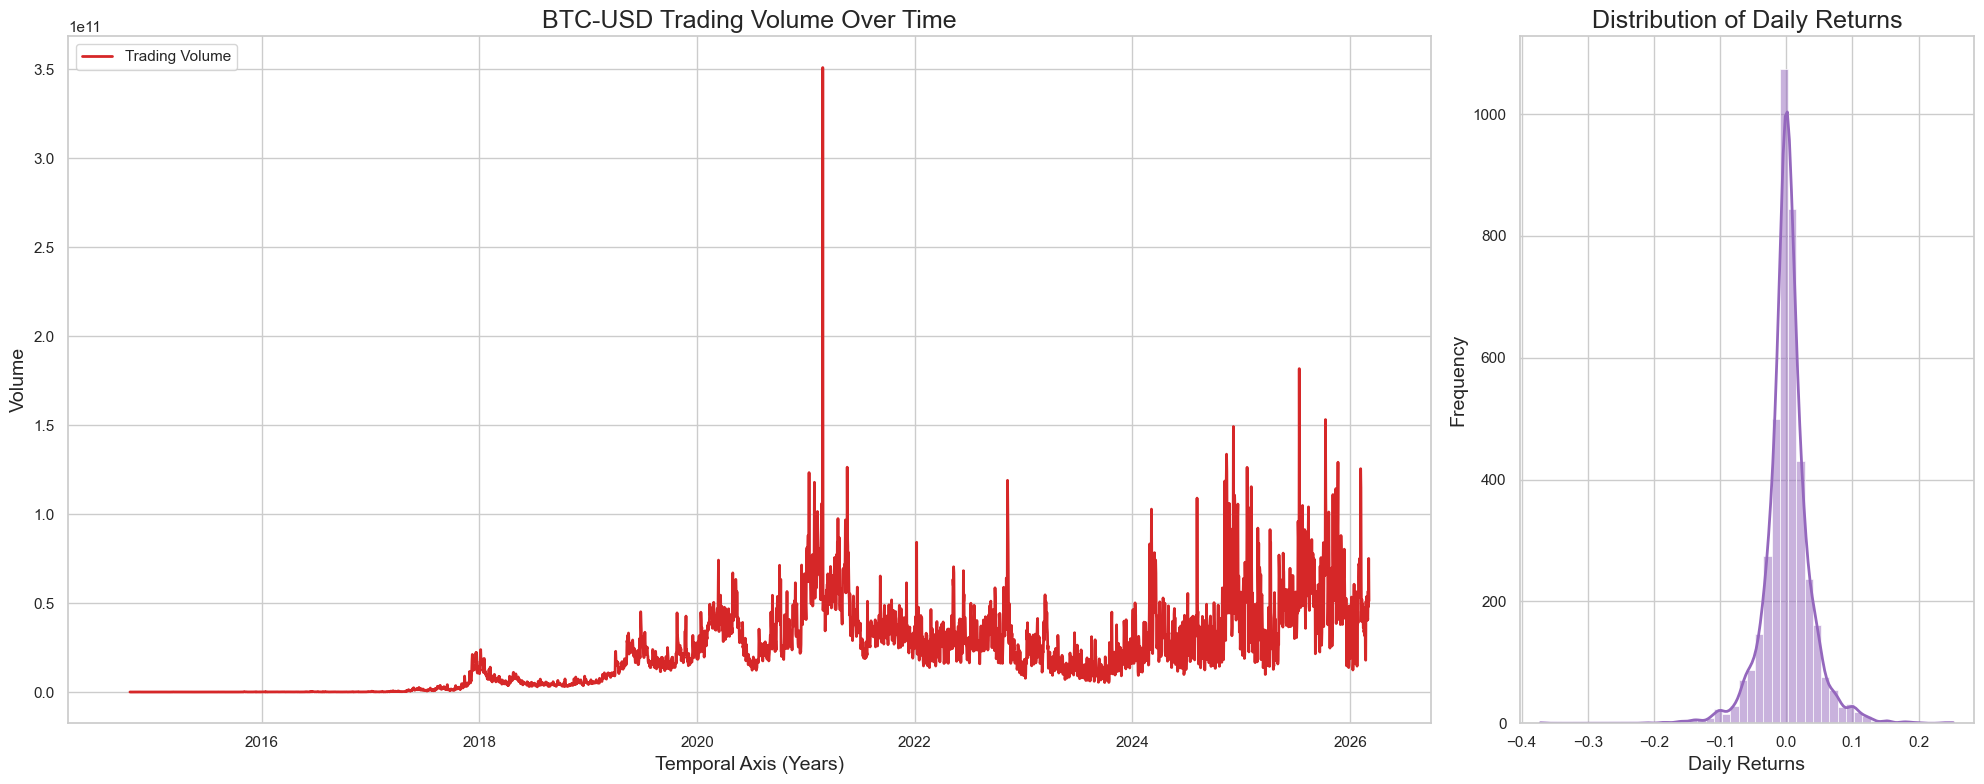

In [8]:
figure, (axis1, axis2) = plt.subplots(1, 2, figsize=(20, 8), gridspec_kw={'width_ratios': [3, 1]})

# Subplot 1: Trading Volume Over Time
axis1.plot(augmentedData['Date'], augmentedData['Volume'], color='#d62728', label='Trading Volume')
axis1.set_title('BTC-USD Trading Volume Over Time')
axis1.set_xlabel('Temporal Axis (Years)')
axis1.set_ylabel('Volume')
axis1.legend(loc='upper left')

# Subplot 2: Distribution of Daily Returns
sns.histplot(augmentedData['dailyReturns'], bins=50, kde=True, ax=axis2, color='#9467bd')
axis2.set_title('Distribution of Daily Returns')
axis2.set_xlabel('Daily Returns')
axis2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

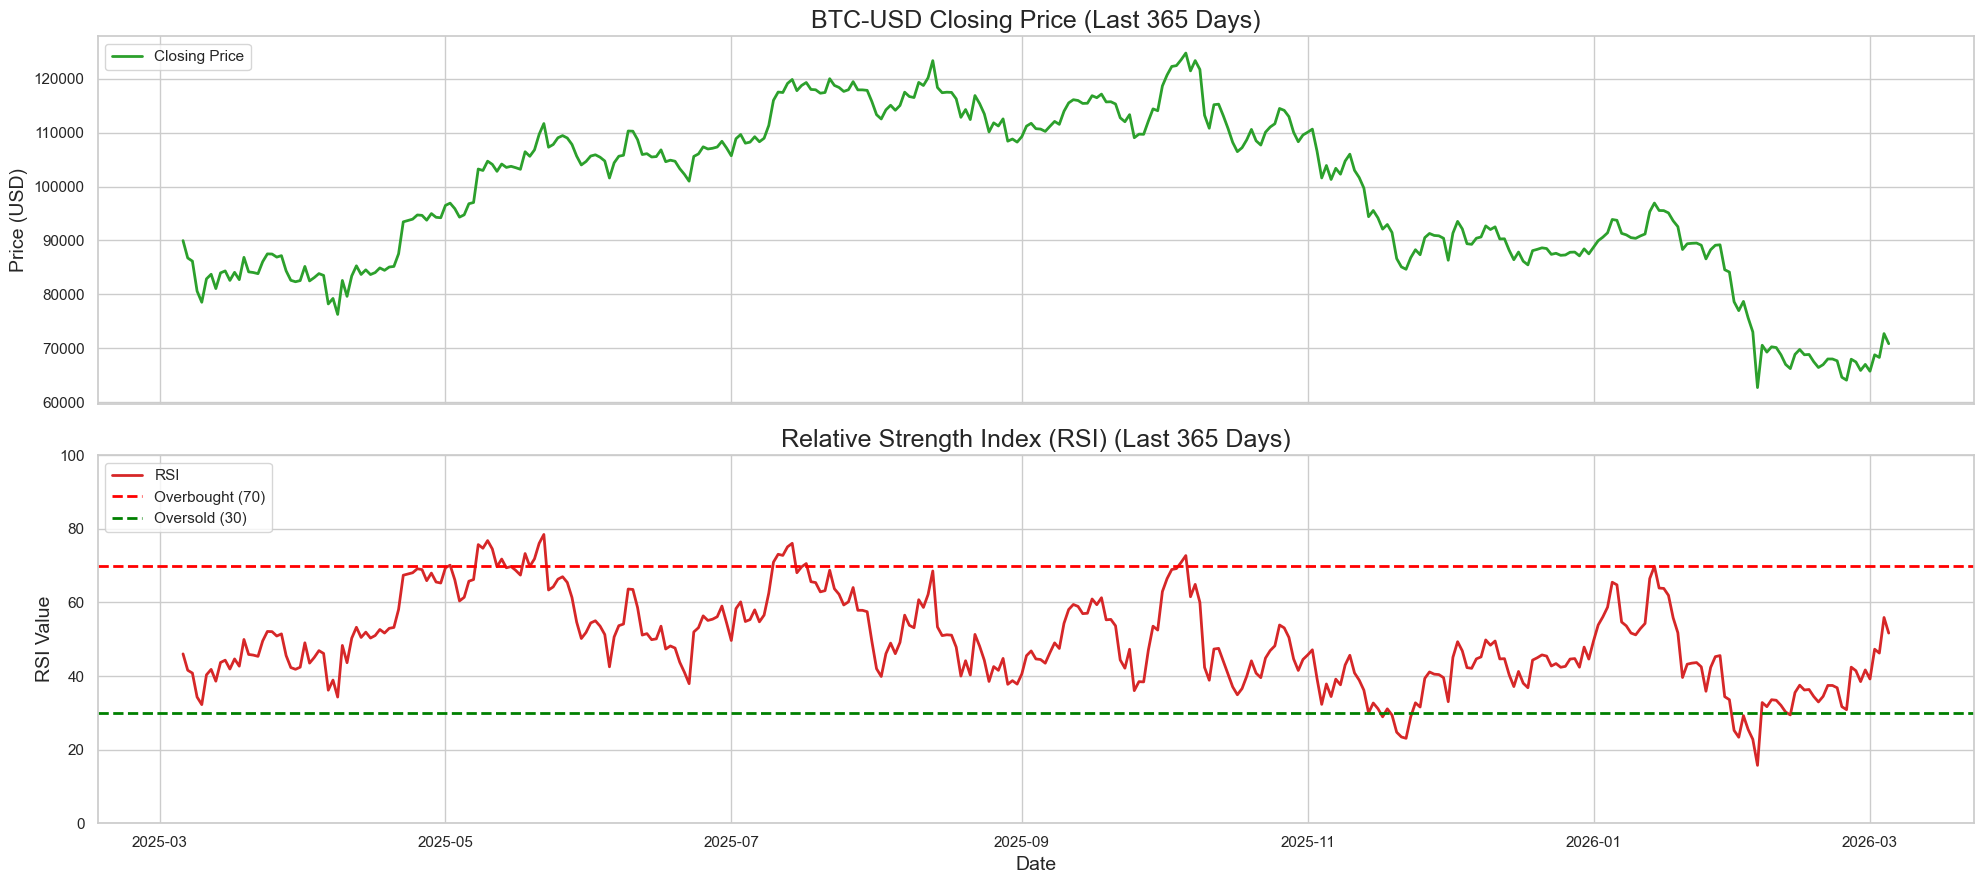

In [9]:
selected_period_data = augmentedData.tail(365)

figure, (axis1, axis2) = plt.subplots(2, 1, figsize=(20, 9), sharex=True)

# Subplot 1: Closing Price
axis1.plot(selected_period_data['Date'], selected_period_data['Close'], color='#2ca02c', label='Closing Price')
axis1.set_title('BTC-USD Closing Price (Last 365 Days)')
axis1.set_ylabel('Price (USD)')
axis1.legend(loc='upper left')
axis1.grid(True)

# Subplot 2: RSI
axis2.plot(selected_period_data['Date'], selected_period_data['rsiValue'], color='#d62728', label='RSI')
axis2.axhline(70, color='red', linestyle='--', label='Overbought (70)')
axis2.axhline(30, color='green', linestyle='--', label='Oversold (30)')
axis2.set_title('Relative Strength Index (RSI) (Last 365 Days)')
axis2.set_xlabel('Date')
axis2.set_ylabel('RSI Value')
axis2.set_ylim(0, 100)
axis2.legend(loc='upper left')
axis2.grid(True)

plt.tight_layout()
plt.show()

### Multi-Collinearity Assessment via Correlation Matrices

Before constructing parametric models (specifically linear ones), diagnosing multi-collinearity within the newly engineered multivariate feature space is theoretically imperative. Highly correlated exogenous variables can destabilize coefficients.


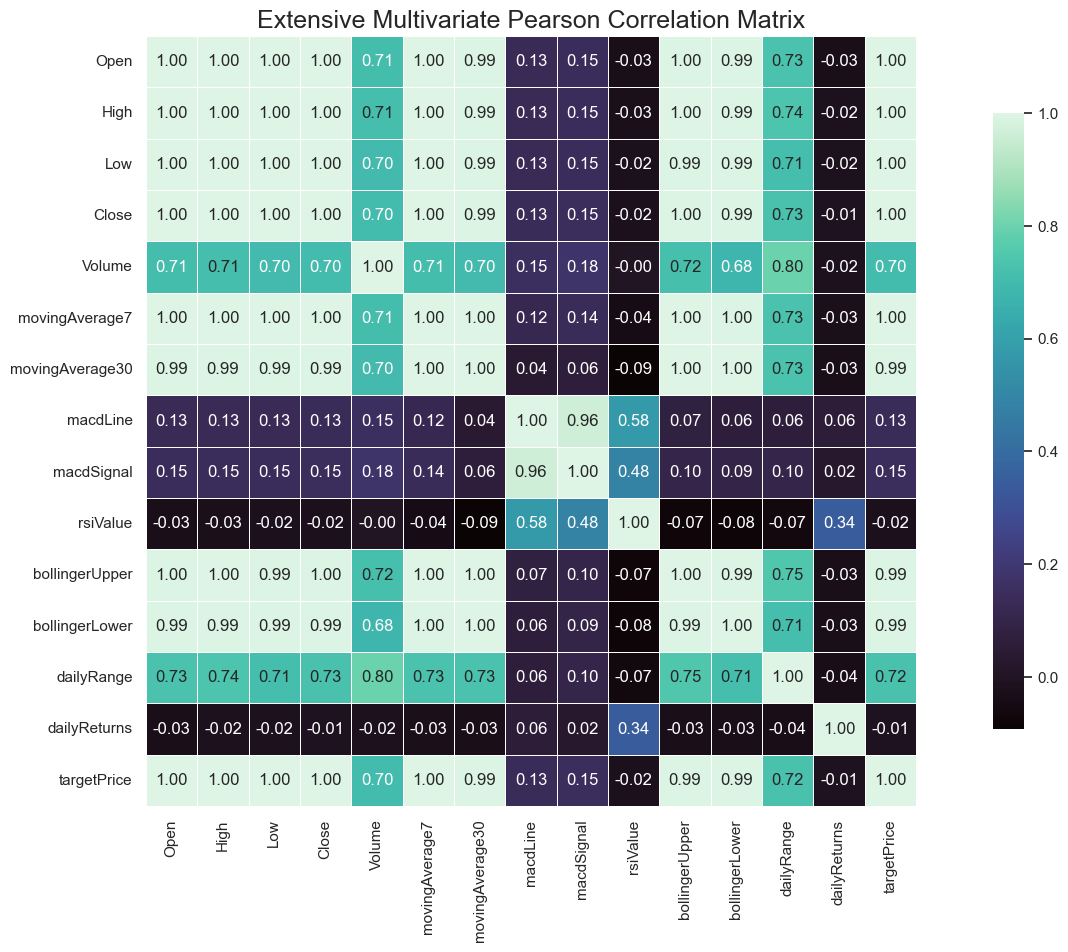

In [10]:
correlationMatrix = augmentedData.drop(columns=['Date']).corr()

plt.figure(figsize=(20, 10))
sns.heatmap(correlationMatrix, annot=True, fmt=".2f", cmap='mako', square=True, linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Extensive Multivariate Pearson Correlation Matrix')
plt.show()


## Phase 3: Algorithmic Modeling & Inference Engine

The predictive architecture is formulated utilizing three distinct, highly optimized algorithmic families:
1. **Linear Regression (Baseline Framework):** Establishing a high-bias, low-variance parametric baseline relying on n-dimensional hyper-plane fitting mechanisms.
2. **Random Forest Regressor:** An ensemble methodology utilizing bootstrapped aggregation across unpruned decision trees. This isolates non-linear interaction terms while radically reducing variance parameters.
3. **Gradient Boosting Regressor:** A robust sequential ensemble technique prioritizing the minimization of pseudo-residuals iteratively. This captures deep systemic anomalies and complex topographical data without enforcing external dependencies like XGBoost.

We systematically partition our multidimensional dataset temporally (maintaining `shuffle=False`) to respect time-series causality constraints.


Operational Training Vector Space: (3327, 13)
Verification Tensor Shape Limit: (832, 13)
Compiling and fitting algorithmic structure for -> Linear Regression
Compiling and fitting algorithmic structure for -> Random Forest
Compiling and fitting algorithmic structure for -> Gradient Boosting

--- Algorithmic Benchmarking Matrix Computation Status: SUCCESS ---


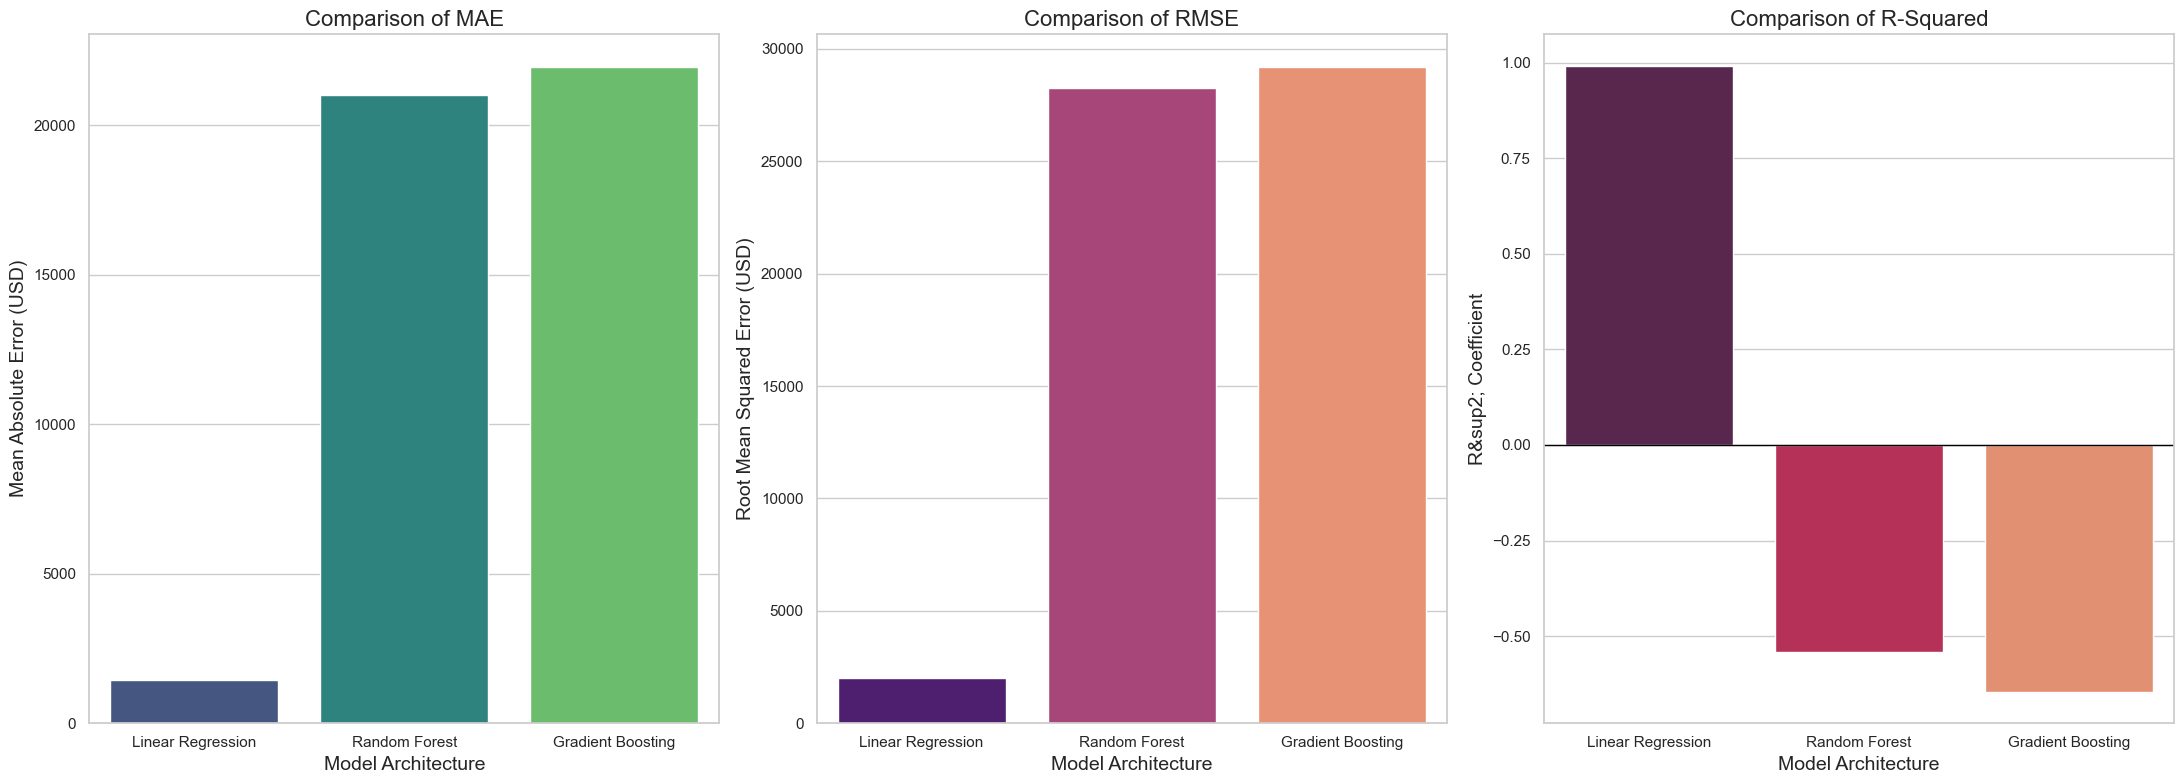

In [11]:
featureColumnsList = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'movingAverage7', 'movingAverage30', 'macdLine', 'macdSignal',
    'rsiValue', 'bollingerUpper', 'bollingerLower', 'dailyRange'
]

designMatrixX = augmentedData[featureColumnsList]
targetVectorY = augmentedData['targetPrice']

# Sequential data slicing
xTrain, xTest, yTrain, yTest = train_test_split(designMatrixX, targetVectorY, test_size=0.2, shuffle=False)

# Normalization Protocol: Coercing convergence vectors via Z-Score Standardization
featureScaler = StandardScaler()
xTrainScaled = featureScaler.fit_transform(xTrain)
xTestScaled = featureScaler.transform(xTest)

print(f"Operational Training Vector Space: {xTrainScaled.shape}")
print(f"Verification Tensor Shape Limit: {xTestScaled.shape}")

# Deep Modeling Registry Configuration
predictiveAlgorithmsRegistry = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=150, max_depth=15, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=150, learning_rate=0.05, max_depth=5, random_state=42)
}

trainedModelsVault = {}
performanceEvaluationMetrics = {}
historicalPredictionsLog = {}

for modelDesignation, machineLearningArchitecture in predictiveAlgorithmsRegistry.items():
    print(f"Compiling and fitting algorithmic structure for -> {modelDesignation}")
    machineLearningArchitecture.fit(xTrainScaled, yTrain)
    inferredTargets = machineLearningArchitecture.predict(xTestScaled)

    # Statistical Coefficient Extraction
    absoluteErrorMean = mean_absolute_error(yTest, inferredTargets)
    squaredErrorMean = mean_squared_error(yTest, inferredTargets)
    rmseValueCalc = np.sqrt(squaredErrorMean)
    rSquaredCoefficient = r2_score(yTest, inferredTargets)

    performanceEvaluationMetrics[modelDesignation] = {
        'MAE': absoluteErrorMean,
        'RMSE': rmseValueCalc,
        'R-Squared': rSquaredCoefficient
    }

    trainedModelsVault[modelDesignation] = machineLearningArchitecture
    historicalPredictionsLog[modelDesignation] = inferredTargets

performanceMetricsDataFrame = pd.DataFrame(performanceEvaluationMetrics).T
print("\n--- Algorithmic Benchmarking Matrix Computation Status: SUCCESS ---")

# Resetting index to use model names as a column for plotting
plotData = performanceMetricsDataFrame.reset_index().rename(columns={'index': 'Model'})

# Creating a figure with 3 subplots in a single row
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

# Subplot 1: Comparison of MAE
sns.barplot(x='Model', y='MAE', data=plotData, ax=axes[0], palette='viridis')
axes[0].set_title('Comparison of MAE', fontsize=16)
axes[0].set_ylabel('Mean Absolute Error (USD)')
axes[0].set_xlabel('Model Architecture')

# Subplot 2: Comparison of RMSE
sns.barplot(x='Model', y='RMSE', data=plotData, ax=axes[1], palette='magma')
axes[1].set_title('Comparison of RMSE', fontsize=16)
axes[1].set_ylabel('Root Mean Squared Error (USD)')
axes[1].set_xlabel('Model Architecture')

# Subplot 3: Comparison of R-Squared
sns.barplot(x='Model', y='R-Squared', data=plotData, ax=axes[2], palette='rocket')
axes[2].axhline(0, color='black', linewidth=1) # Adding a baseline for 0
axes[2].set_title('Comparison of R-Squared', fontsize=16)
axes[2].set_ylabel('R&sup2; Coefficient')
axes[2].set_xlabel('Model Architecture')

# Optimizing layout
plt.tight_layout()
plt.show()



## Phase 4: Extreme Visual Diagnostics & Algorithmic Comparison

Beyond raw scalar metrics, an uncompromisingly rigorous evaluation pipeline demands granular visual diagnostics. We overlay ground-truth target valuations against the predictive capacity vectors synthesized by our ensemble. Furthermore, performing heteroscedasticity checks against residual variance determines whether systematic biases persist un-captured.


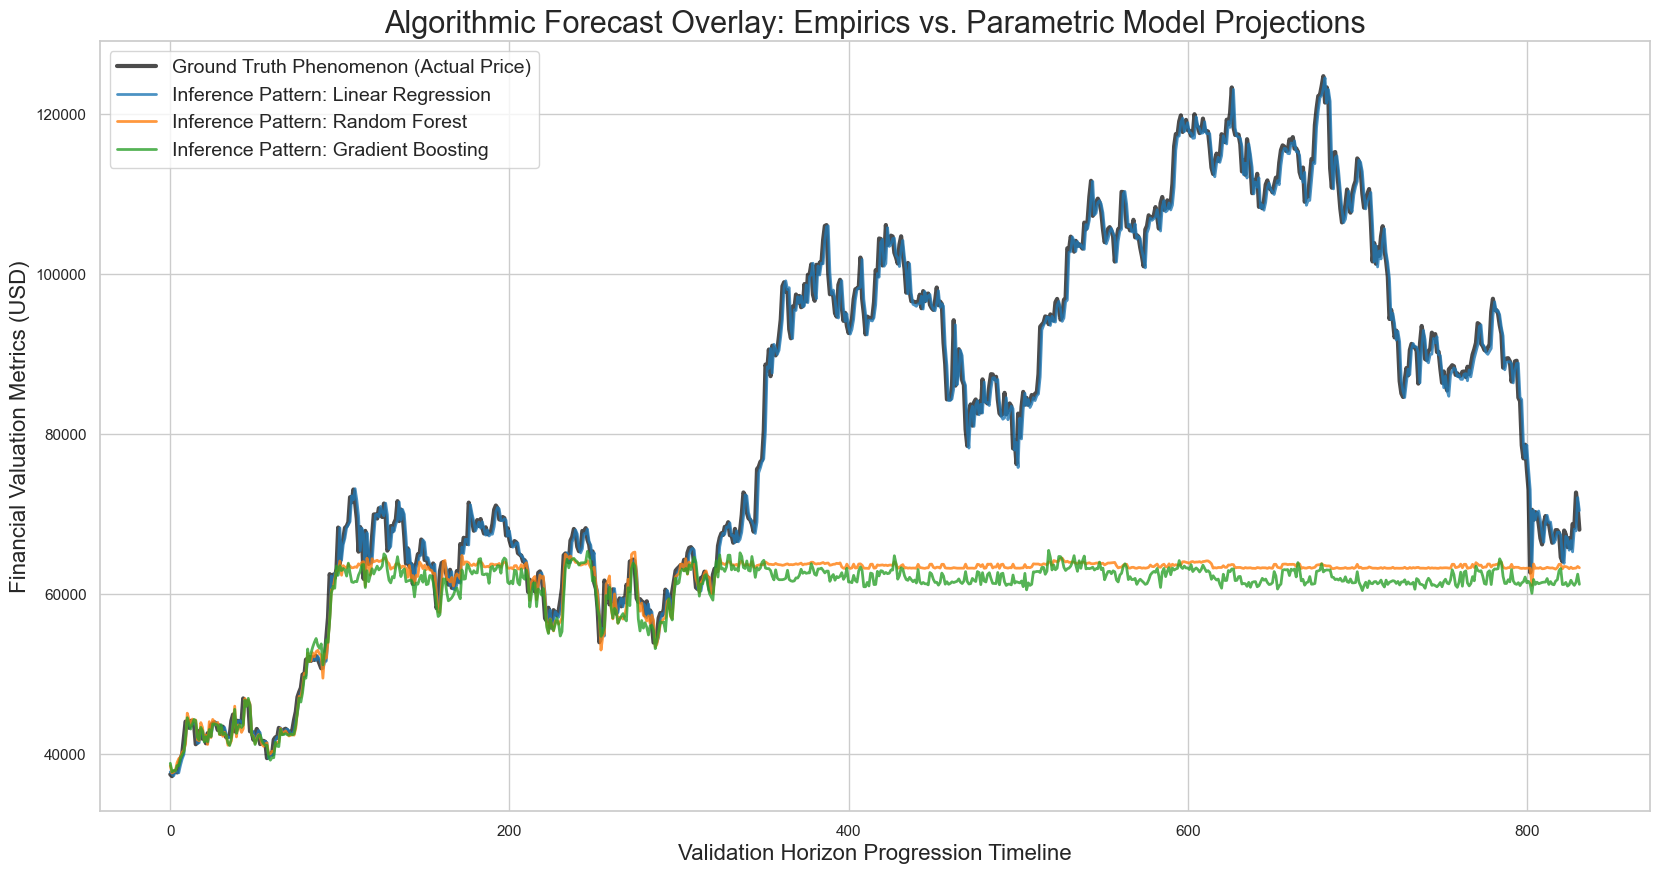

In [12]:
# Rendering Advanced Visualization Architectures for Predictive Capacities
plt.figure(figsize=(20, 10))
plt.plot(yTest.values, label='Ground Truth Phenomenon (Actual Price)', color='black', linewidth=3, alpha=0.7)

aestheticColorMapping = {
    'Linear Regression': '#1f77b4',
    'Random Forest': '#ff7f0e',
    'Gradient Boosting': '#2ca02c'
}

for algorithmIdentifier, modelPredictionsArray in historicalPredictionsLog.items():
    plt.plot(modelPredictionsArray, label=f'Inference Pattern: {algorithmIdentifier}',
             color=aestheticColorMapping[algorithmIdentifier], alpha=0.8)

plt.title('Algorithmic Forecast Overlay: Empirics vs. Parametric Model Projections', fontsize=22)
plt.xlabel('Validation Horizon Progression Timeline', fontsize=16)
plt.ylabel('Financial Valuation Metrics (USD)', fontsize=16)
plt.legend(fontsize=14, loc='upper left')
plt.show()


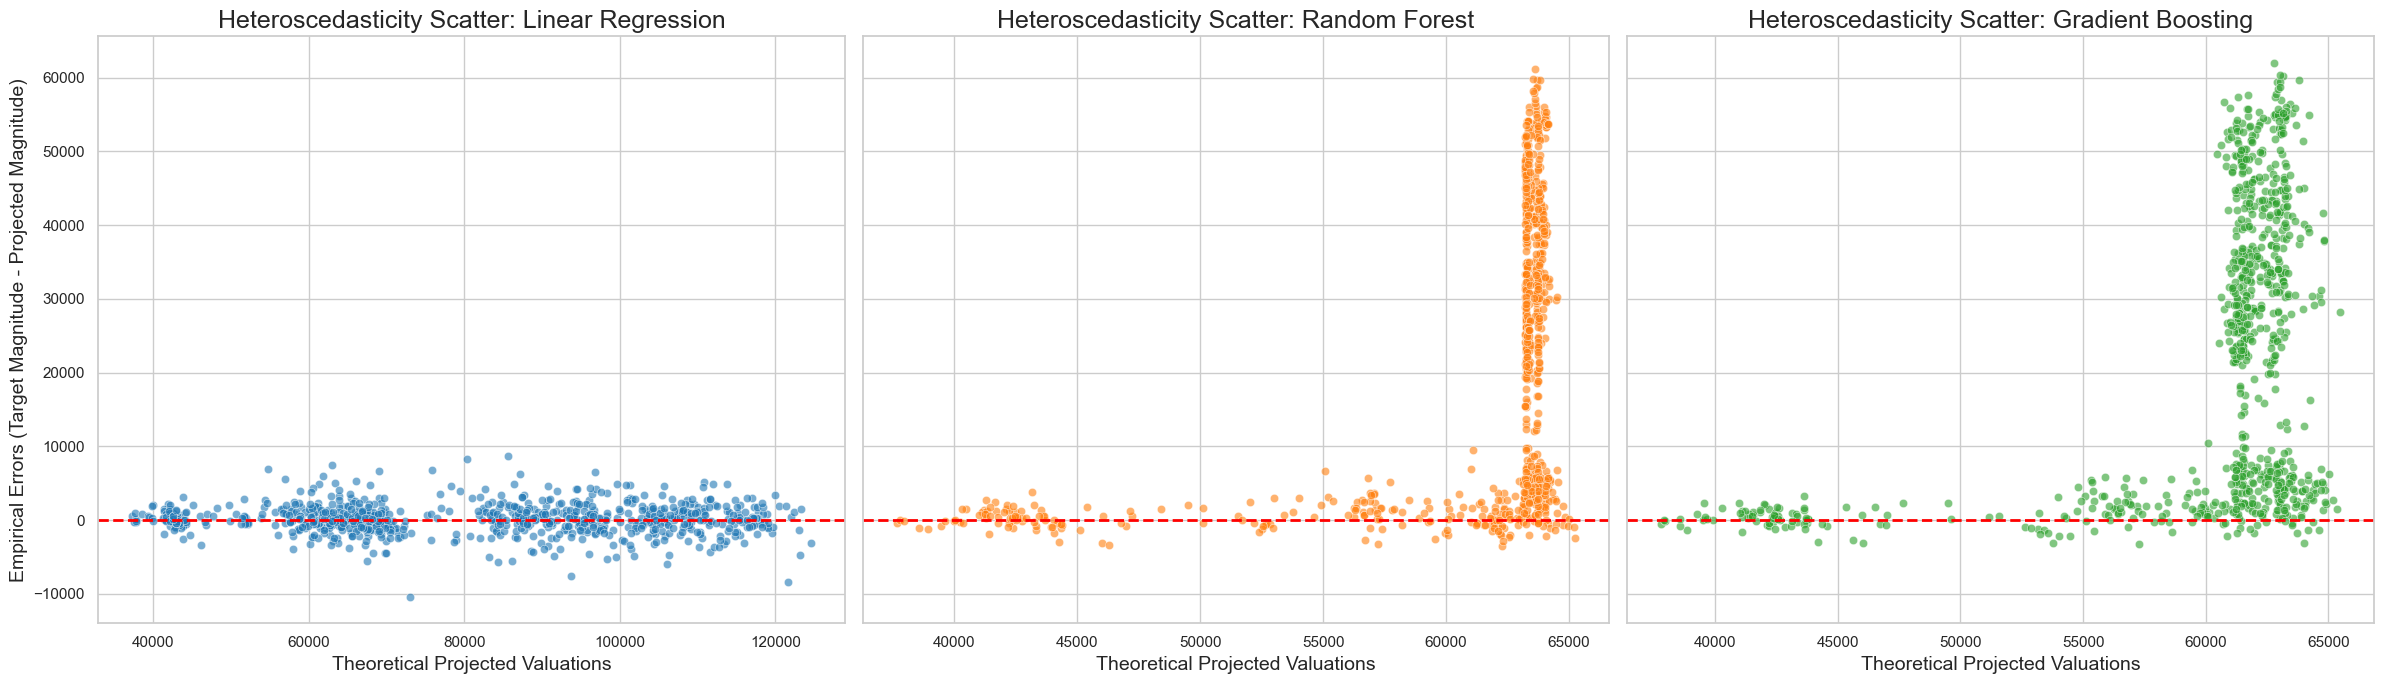

In [13]:
# Deep Diagnostics: Multi-Algorithmic Residual Deviation Scatters
figureStruct, subplotAxes = plt.subplots(1, 3, figsize=(24, 7), sharey=True)

for iteratorIndex, (algorithmIdentifier, modelPredictionsArray) in enumerate(historicalPredictionsLog.items()):
    computationalResiduals = yTest.values - modelPredictionsArray
    sns.scatterplot(x=modelPredictionsArray, y=computationalResiduals, ax=subplotAxes[iteratorIndex],
                    color=aestheticColorMapping[algorithmIdentifier], alpha=0.6)
    subplotAxes[iteratorIndex].axhline(0, color='red', linestyle='--', linewidth=2)
    subplotAxes[iteratorIndex].set_title(f'Heteroscedasticity Scatter: {algorithmIdentifier}')
    subplotAxes[iteratorIndex].set_xlabel('Theoretical Projected Valuations')
    if iteratorIndex == 0:
        subplotAxes[iteratorIndex].set_ylabel('Empirical Errors (Target Magnitude - Projected Magnitude)')

plt.tight_layout()
plt.show()


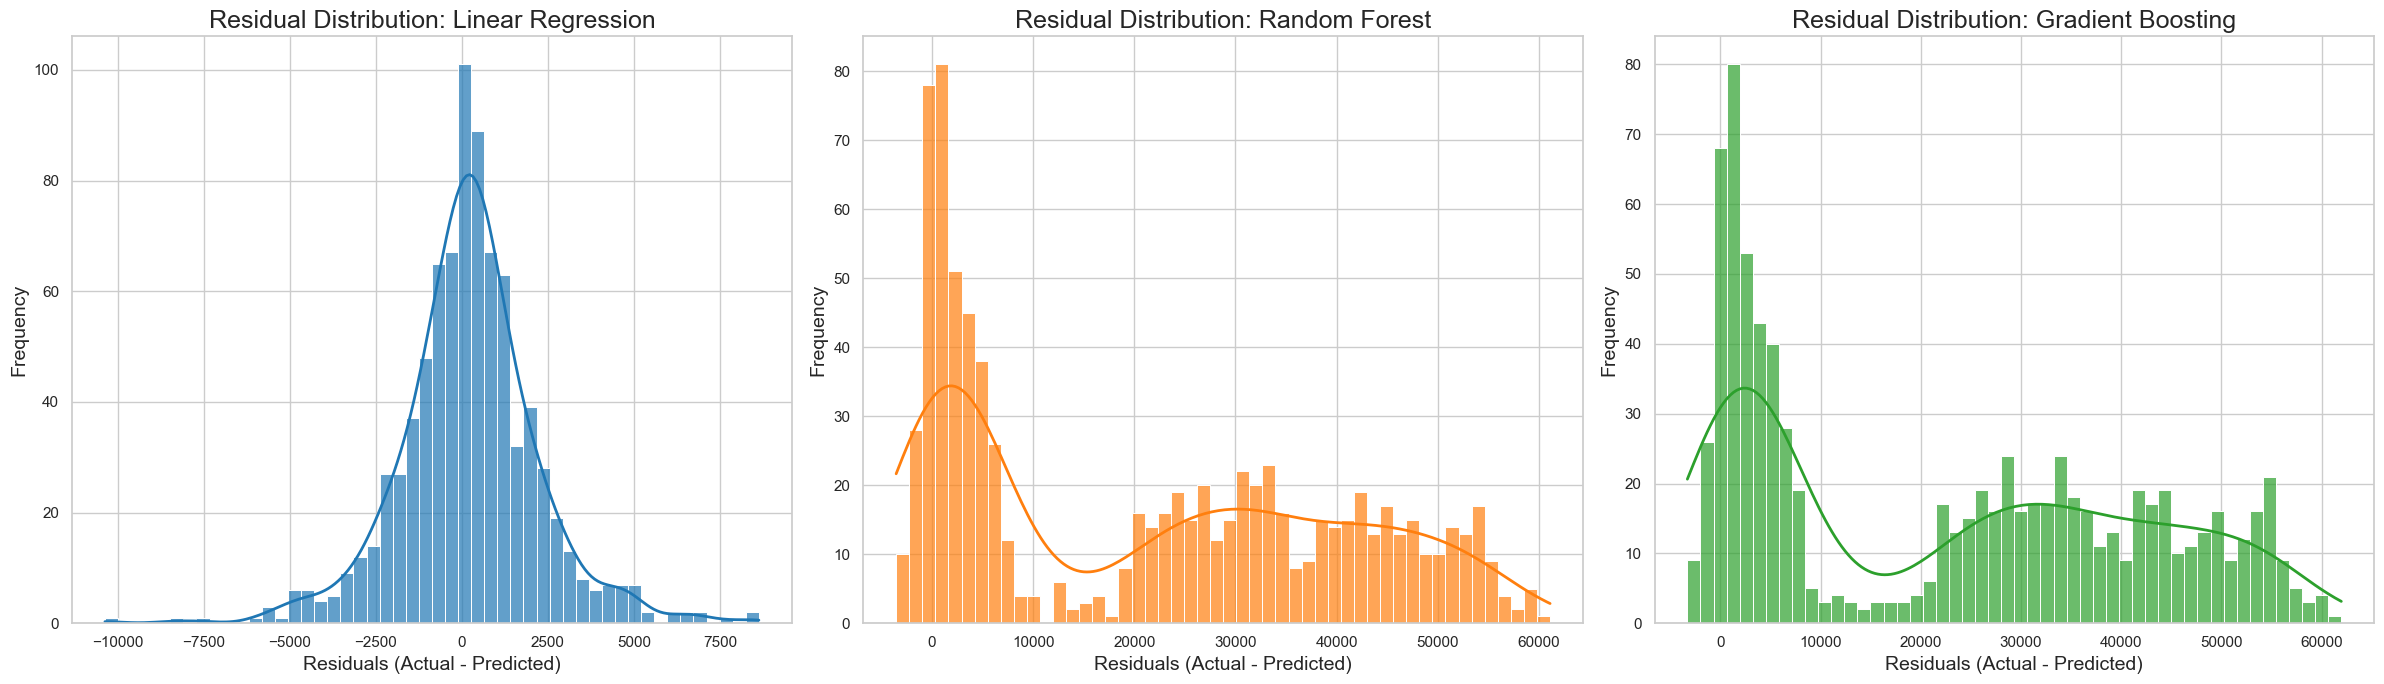

In [14]:
figure, subplotAxes = plt.subplots(1, len(historicalPredictionsLog), figsize=(len(historicalPredictionsLog) * 8, 7))

for iteratorIndex, (algorithmIdentifier, modelPredictionsArray) in enumerate(historicalPredictionsLog.items()):
    computationalResiduals = yTest.values - modelPredictionsArray
    sns.histplot(computationalResiduals, kde=True, ax=subplotAxes[iteratorIndex],
                 color=aestheticColorMapping[algorithmIdentifier], alpha=0.7, bins=50)
    subplotAxes[iteratorIndex].set_title(f'Residual Distribution: {algorithmIdentifier}')
    subplotAxes[iteratorIndex].set_xlabel('Residuals (Actual - Predicted)')
    subplotAxes[iteratorIndex].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Architectural Interpretability: Gini Feature Importance

To ensure robust interpretability of our internal systems, we decompose the decision trees within our premium Gradient Boosting topology. This empirically verifies and ranks which mathematically synthesized features delivered the most consequential predictive signal payload during phase-space interpolation.


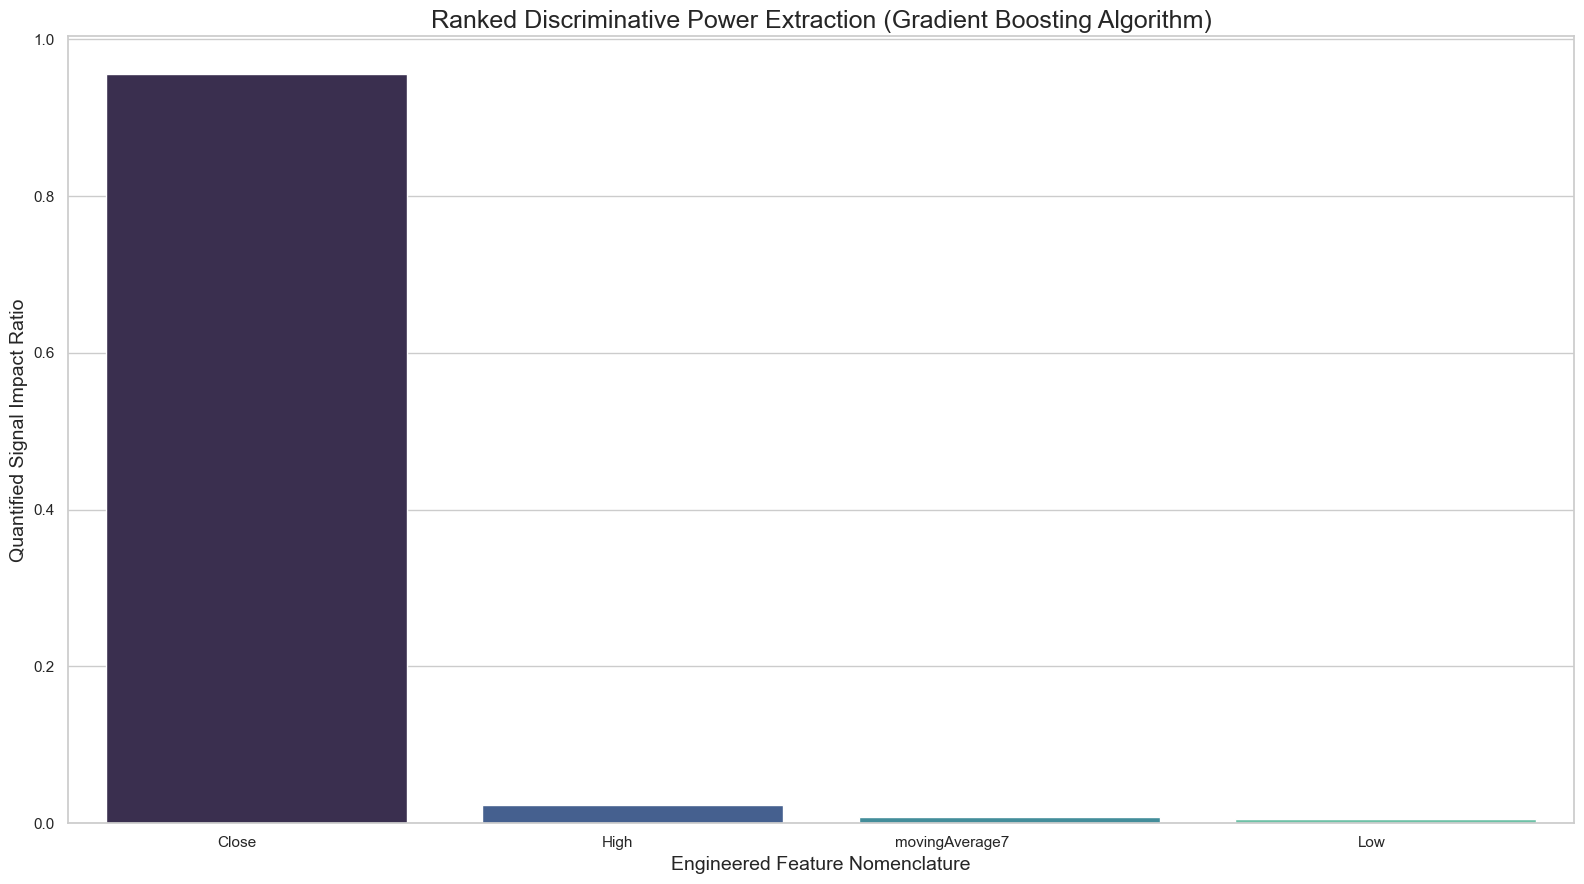

In [15]:
elitePredictorCore = trainedModelsVault['Gradient Boosting']
extractedImportanceMetrics = elitePredictorCore.feature_importances_

featureUtilityDataFrame = pd.DataFrame({
    'Feature Designation Variables': featureColumnsList,
    'Gini Importance Coefficient Payload': extractedImportanceMetrics
}).sort_values(by='Gini Importance Coefficient Payload', ascending=False)

plt.figure(figsize=(16, 9))
sns.barplot(x='Feature Designation Variables', y='Gini Importance Coefficient Payload',
            data=featureUtilityDataFrame[featureUtilityDataFrame['Gini Importance Coefficient Payload'] >= 0.005], palette='mako')
plt.title('Ranked Discriminative Power Extraction (Gradient Boosting Algorithm)', fontsize=18)
plt.xlabel('Engineered Feature Nomenclature')
plt.ylabel('Quantified Signal Impact Ratio')
plt.xticks(ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

## Phase 5: Operational Readiness Serialization Pipeline

To externalize and operationalize our algorithmic topologies efficiently via an asynchronous, strictly-typed **Streamlit Application Layer**, we meticulously serialize our standardized multi-dimensional scaler variables and the superlative Gradient Boosting Regressor artifacts directly into system memory drives.


In [18]:
import joblib

# Persisting all model artifacts from the vault
for modelName, modelObject in trainedModelsVault.items():
    fileName = f"../models/{modelName.lower().replace(' ', '_')}_model.pkl"
    joblib.dump(modelObject, fileName)
    print(f"Serialized: {fileName}")

# Persisting shared artifacts
joblib.dump(featureScaler, '../models/feature_scaler.pkl')
augmentedData.to_csv('../data/refined_btc_data.csv', index=False)

print("\nSystem Memory Extraction Finished! All model artifacts, 'feature_scaler.pkl', and 'refined_btc_data.csv' stored successfully.")
print("Pipeline Successfully Processed. Proceed with invoking: 'streamlit run app.py'")

Serialized: ../models/linear_regression_model.pkl
Serialized: ../models/random_forest_model.pkl
Serialized: ../models/gradient_boosting_model.pkl

System Memory Extraction Finished! All model artifacts, 'feature_scaler.pkl', and 'refined_btc_data.csv' stored successfully.
Pipeline Successfully Processed. Proceed with invoking: 'streamlit run app.py'
